# Apple Stock (part a)

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [125]:
# In step 3

### Step 3. Assign it to a variable apple

In [126]:
apple = pd.read_csv("https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv", sep = ",")

### Step 4.  Check out the type of the columns

In [127]:
apple.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

### Step 5. Transform the Date column as a datetime type

In [128]:
apple['Date'] = pd.to_datetime(apple['Date'])

### Step 6.  Set the date as the index

In [129]:
apple = apple.set_index("Date")

### Step 7.  Is there any duplicate dates?

In [130]:
len(list(apple.index)) - len(list(set(list(apple.index)))) != 0

False

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [131]:
apple = apple.sort_index(axis=0)

### Step 9. Get the last business day of each month

In [132]:
#MonthEnd(0) gives the last day of the month
apple.loc[(apple.index + pd.offsets.BMonthEnd(0)).day == apple.index.day]

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-01-30,28.50,28.50,28.25,28.25,11547200,0.44
1981-02-27,26.50,26.75,26.50,26.50,3690400,0.41
1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44
...,...,...,...,...,...,...
2014-02-28,529.08,532.75,522.12,526.24,92992200,74.76
2014-03-31,539.23,540.81,535.93,536.74,42167300,76.25
2014-04-30,592.64,599.43,589.80,590.09,114160200,83.83


### Step 10.  What is the difference in days between the first day and the oldest

In [133]:
(apple.index[-1] - apple.index[0]).days

12261

### Step 11.  How many months in the data we have?

In [149]:
# If the meaning if for different months of the year
different_months_of_the_year = len(apple.groupby([apple.index.month]).count().index)

# If the meaning if for different months in general
different_months_general = len(apple.groupby(pd.Grouper(freq="ME")).count().index)

print(different_months_general)

404


### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

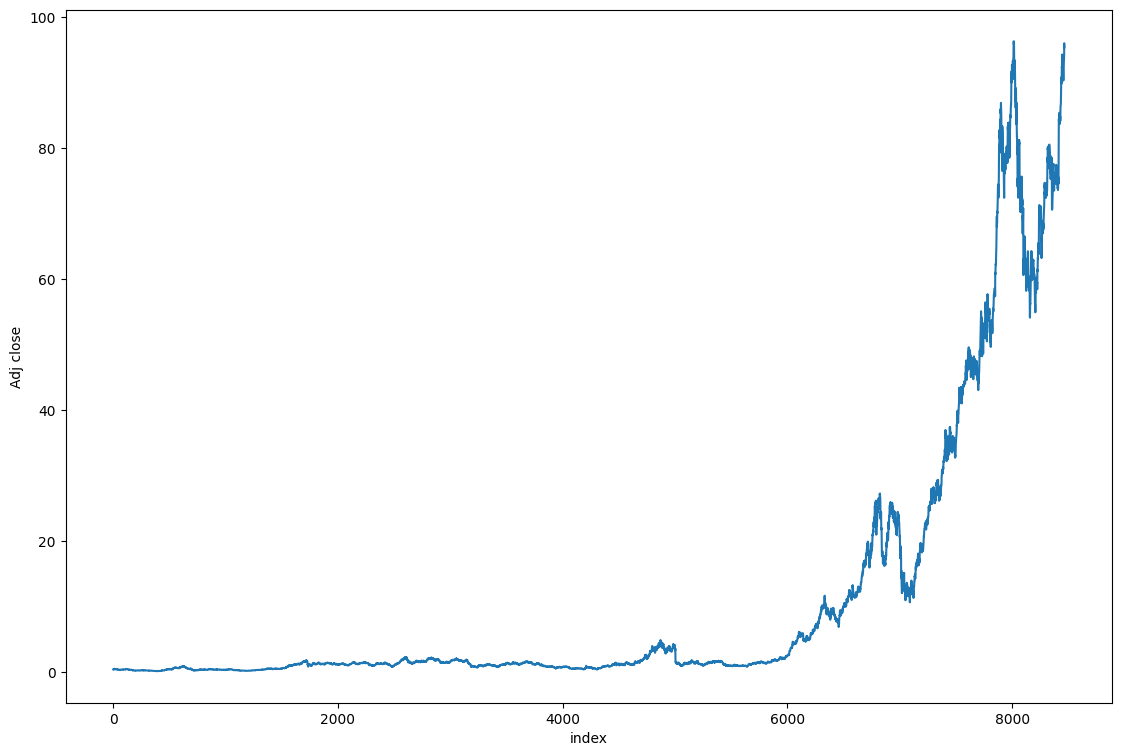

In [156]:
plt.figure(figsize=(13.5, 9));
plt.plot(apple["Adj Close"]);
plt.ylabel("Adj close");
plt.xlabel("Date");

### BONUS: Create your own question and answer it.

count    8465.000000
mean        0.025386
std         2.488824
min       -19.222304
25%        -1.169822
50%         0.000000
75%         1.298701
max        24.352332
dtype: float64

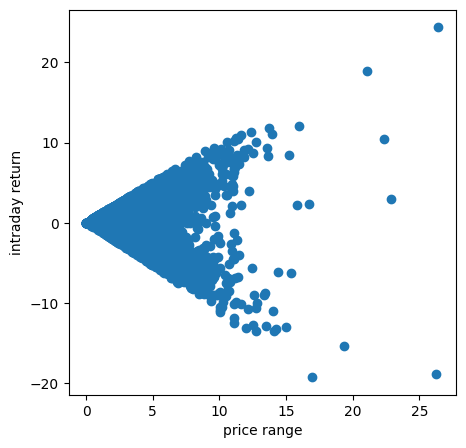

In [172]:
# Plot the intraday return with respect to the price range (for each day)
# Show the statistics the stock change

intraday_return = (apple["Open"] - apple["Close"])/apple["Open"] * 100
price_range = (apple["High"] - apple["Low"])/apple["High"] * 100

plt.figure(figsize=(5, 5));
plt.scatter(price_range, intraday_return);
plt.xlabel("price range");
plt.ylabel("intraday return");

intraday_return.describe()